# Project 2: Predictive Modeling and Engineering Optimization  
**Caleb VanVooren**  
MSPE 49600  
Purdue University


In [5]:
import pandas as pd

# Task 1: Setup-Level Data Preparation

### Read and summarize the data

In [28]:
# Step 1
df_raw = pd.read_csv("ims_setup_project02.csv")

# Step 2
df_raw.head()  # first five rows
df_raw.shape  # number of rows and columns
df_raw.columns         # column names
df_raw.describe()      # descriptive statistics
df_raw.isna().sum()    # missing values per column


lap                    0
rear_wing_angle_deg    0
rear_ride_height_mm    0
sector_3_time_s        0
top_speed_kph          0
dtype: int64

In [29]:
# Step 3

# Select required columns
df = df_raw[[
    "lap",
    "rear_wing_angle_deg",
    "rear_ride_height_mm",
    "sector_3_time_s",
    "top_speed_kph"
]].copy()

# Convert to numeric (coerce errors → NaN)
df = df.apply(pd.to_numeric, errors="coerce")

# Remove exact duplicates
df = df.drop_duplicates()

# Remove rows with missing values in ANY required column
df = df.dropna()

df.head(), df.shape



(   lap  rear_wing_angle_deg  rear_ride_height_mm  sector_3_time_s  \
 0    1                    5                   35          33.0949   
 1    2                    5                   35          32.9325   
 2    3                    5                   35          33.0858   
 3    4                    5                   35          33.0472   
 4    5                    5                   35          33.0534   
 
    top_speed_kph  
 0        286.761  
 1        287.079  
 2        287.261  
 3        287.059  
 4        287.463  ,
 (135, 5))

### Create the setup-level DataFrame

In [30]:
# Step 4: Group by rear_wing_angle_deg and rear_ride_height_mm
df_grouped = df.groupby(
    ["rear_wing_angle_deg", "rear_ride_height_mm"]
).agg(
    mean_sector_3_time_s=("sector_3_time_s", "mean"),
    std_sector_3_time_s=("sector_3_time_s", "std"),
    mean_top_speed_kph=("top_speed_kph", "mean"),
    std_top_speed_kph=("top_speed_kph", "std"),
    valid_laps=("sector_3_time_s", "count")
).reset_index()


In [31]:
# Step 5: Display grouped results + count setups
df_grouped
len(df_grouped)

27

In [32]:
# Step 6: Save grouped DataFrame
df_grouped.to_csv("cvanvoor_pr02_grouped.csv", index=False)

# Task 2: Quadratic Surrogate Models and Validation 

In [23]:
# Step 7: Train/Test Split (75% / 25%)

import numpy as np
from IPython.display import display

# Set seed for reproducibility
np.random.seed(42)

# Shuffle the indices
indices = np.random.permutation(len(df_grouped))

# Compute split point (75% train, 25% test)
split_point = int(0.75 * len(df_grouped))

train_idx = indices[:split_point]
test_idx = indices[split_point:]

df_train = df_grouped.iloc[train_idx].reset_index(drop=True)
df_test = df_grouped.iloc[test_idx].reset_index(drop=True)

len(df_train), len(df_test)

display(df_train)      # shows the DataFrame
display(df_test)       # shows the DataFrame

# Step 8: Display number of configurations in train/test sets
print("Training configurations:", len(df_train))
print("Test configurations:", len(df_test))



,rear_wing_angle_deg,rear_ride_height_mm,mean_sector_3_time_s,std_sector_3_time_s,mean_top_speed_kph,std_top_speed_kph,valid_laps
0,7,45,32.01484,0.053106,285.0412,0.182341,5
1,9,40,31.34738,0.065261,284.4520,0.247720,5
2,8,35,31.68490,0.054910,285.3770,0.150690,5
3,12,35,31.41880,0.050465,282.3054,0.197818,5
4,5,35,33.04276,0.064925,287.1246,0.260628,5
5,8,45,31.73018,0.051285,284.4710,0.175812,5
6,10,40,31.18592,0.071789,283.6652,0.211002,5
7,10,45,31.44488,0.032345,283.2168,0.147854,5
8,9,35,31.44076,0.077286,284.6556,0.126069,5
9,13,35,31.59024,0.068500,281.6042,0.252946,5


,rear_wing_angle_deg,rear_ride_height_mm,mean_sector_3_time_s,std_sector_3_time_s,mean_top_speed_kph,std_top_speed_kph,valid_laps
0,13,45,31.80864,0.038250,281.1722,0.315575,5
1,11,45,31.43942,0.032349,282.4834,0.204149,5
2,7,40,31.86244,0.059775,285.3564,0.242663,5
3,8,40,31.55450,0.047185,284.7830,0.088521,5
4,9,45,31.54258,0.053595,284.0304,0.190648,5
5,11,40,31.26602,0.076328,282.9070,0.206211,5
6,7,35,32.03248,0.035651,285.8530,0.289042,5


Training configurations: 20
Test configurations: 7


## Step 8: Markdown Explanation

- ### Why the train/test split is performed *after* grouping the repeated laps

The train/test split is done after grouping because the goal is to evaluate how well the response‑surface model
predicts *setup configurations*, not individual laps. Each setup has multiple laps, and those laps are not
independent observations — they are repeated measurements of the same configuration.

If we split before grouping, laps from the same setup could end up in both the training and test sets. That would
leak information from training into testing, artificially improving the model’s performance.

By grouping first and then splitting, each setup configuration appears **only in training or only in testing**, which
provides a valid and unbiased evaluation of how well the model generalizes to unseen setups.


### Quadratic response surfaces

In [24]:
# Step 9: Define
import numpy as np
from IPython.display import display

def create_design_matrix(x1, x2):
    """
    Returns a quadratic design matrix with columns:
    [1, x1, x2, x1**2, x2**2, x1*x2]
    """
    return np.column_stack([
        np.ones_like(x1),
        x1,
        x2,
        x1**2,
        x2**2,
        x1 * x2
    ])


In [25]:
# Step 10: Fit quadratic model for mean Sector 3 time

# Extract training variables
x1_train = df_train["rear_wing_angle_deg"].to_numpy()
x2_train = df_train["rear_ride_height_mm"].to_numpy()

y_time_train = df_train["mean_sector_3_time_s"].to_numpy()

# Build design matrix
X_time_train = create_design_matrix(x1_train, x2_train)

# Fit using Moore–Penrose pseudoinverse
b_time_train = np.linalg.pinv(X_time_train) @ y_time_train

print("Sector 3 time coefficients:")
print(b_time_train)


Sector 3 time coefficients:
[ 4.79189016e+01 -1.30917361e+00 -5.05272198e-01  5.49743351e-02
  5.97544433e-03  3.88621117e-03]


In [26]:
# Step 11: Fit quadratic model for mean top speed
y_speed_train = df_train["mean_top_speed_kph"].to_numpy()

X_speed_train = create_design_matrix(x1_train, x2_train)

b_speed_train = np.linalg.pinv(X_speed_train) @ y_speed_train

print("Top speed coefficients:")
print(b_speed_train)


Top speed coefficients:
[ 2.86383488e+02 -4.72984903e-01  2.29072512e-01 -1.38523866e-02
 -3.86554324e-03  1.00778439e-03]


In [27]:
# Step 12: Display both coefficient vectors + write equations
print("Quadratic model coefficients for Sector 3 time:")
print(b_time_train)

print("\nQuadratic model coefficients for Top Speed:")
print(b_speed_train)


Quadratic model coefficients for Sector 3 time:
[ 4.79189016e+01 -1.30917361e+00 -5.05272198e-01  5.49743351e-02
  5.97544433e-03  3.88621117e-03]

Quadratic model coefficients for Top Speed:
[ 2.86383488e+02 -4.72984903e-01  2.29072512e-01 -1.38523866e-02
 -3.86554324e-03  1.00778439e-03]


## Step 12: Markdown Cell

### Quadratic Response Surface Models

We fit two second‑order polynomial models of the form:

$$
\hat{y}(x_1, x_2) =
b_0 + b_1 x_1 + b_2 x_2 + b_3 x_1^2 + b_4 x_2^2 + b_5 x_1 x_2
$$

where  
- \(x_1\) = rear‑wing angle (deg)  
- \(x_2\) = rear ride height (mm)

---

### Fitted Model for Mean Sector 3 Time

Coefficient vector:

$$
[b_0,\ b_1,\ b_2,\ b_3,\ b_4,\ b_5] =
[ 4.79189016e+01, \ -1.30917361e+00, \ -5.05272198e-01, \ 5.49743351e-02,
 \ 5.97544433e-03, \ 3.88621117e-03]
$$

So the fitted equation is:

$$
\hat{t}_{S3}(x_1, x_2) =
b_0 + b_1 x_1 + b_2 x_2 + b_3 x_1^2 + b_4 x_2^2 + b_5 x_1 x_2
$$

---

### Fitted Model for Mean Top Speed

Coefficient vector:

$$
[b_0,\ b_1,\ b_2,\ b_3,\ b_4,\ b_5] =
[ 2.86383488e+02, \ -4.72984903e-01, \  2.29072512e-01, \ -1.38523866e-02, \
 -3.86554324e-03, \  1.00778439e-03]
$$

Fitted equation:

$$
\hat{v}(x_1, x_2) =
b_0 + b_1 x_1 + b_2 x_2 + b_3 x_1^2 + b_4 x_2^2 + b_5 x_1 x_2
$$


### Validation and final surrogate models

In [33]:
# Step 13: Predict mean Sector 3 time and mean top speed for test configurations

from IPython.display import display

# Extract test variables
x1_test = df_test["rear_wing_angle_deg"].to_numpy()
x2_test = df_test["rear_ride_height_mm"].to_numpy()

# Build design matrix for test set
X_test = create_design_matrix(x1_test, x2_test)

# Predictions
y_time_test_pred = X_test @ b_time_train
y_speed_test_pred = X_test @ b_speed_train

print("Predicted Sector 3 times (test set):")
display(y_time_test_pred)

print("Predicted top speeds (test set):")
display(y_speed_test_pred)


Predicted Sector 3 times (test set):


array([31.82676678, 31.4565869 , 31.88639093, 31.5572808 , 31.5262017 ,
       31.22964243, 32.0359429 ])

Predicted top speeds (test set):


array([280.96372324, 282.48390701, 285.65403812, 285.0135788 ,
       283.89327168, 282.92597218, 285.92298183])

In [34]:
# Step 14: Compute RMSE and R², store in df_validation, save CSV

# Actual test responses
y_time_test = df_test["mean_sector_3_time_s"].to_numpy()
y_speed_test = df_test["mean_top_speed_kph"].to_numpy()

# RMSE
rmse_time = np.sqrt(np.mean((y_time_test - y_time_test_pred)**2))
rmse_speed = np.sqrt(np.mean((y_speed_test - y_speed_test_pred)**2))

# R^2
r2_time = 1 - np.sum((y_time_test - y_time_test_pred)**2) / np.sum((y_time_test - np.mean(y_time_test))**2)
r2_speed = 1 - np.sum((y_speed_test - y_speed_test_pred)**2) / np.sum((y_speed_test - np.mean(y_speed_test))**2)

# Build validation DataFrame
df_validation = pd.DataFrame({
    "response": ["sector_3_time", "top_speed"],
    "rmse": [rmse_time, rmse_speed],
    "r2": [r2_time, r2_speed]
})

display(df_validation)

# Save
df_validation.to_csv("cvanvoor_pr02_validation.csv", index=False)


,response,rmse,r2
0,sector_3_time,0.020029,0.993450
1,top_speed,0.172908,0.987756


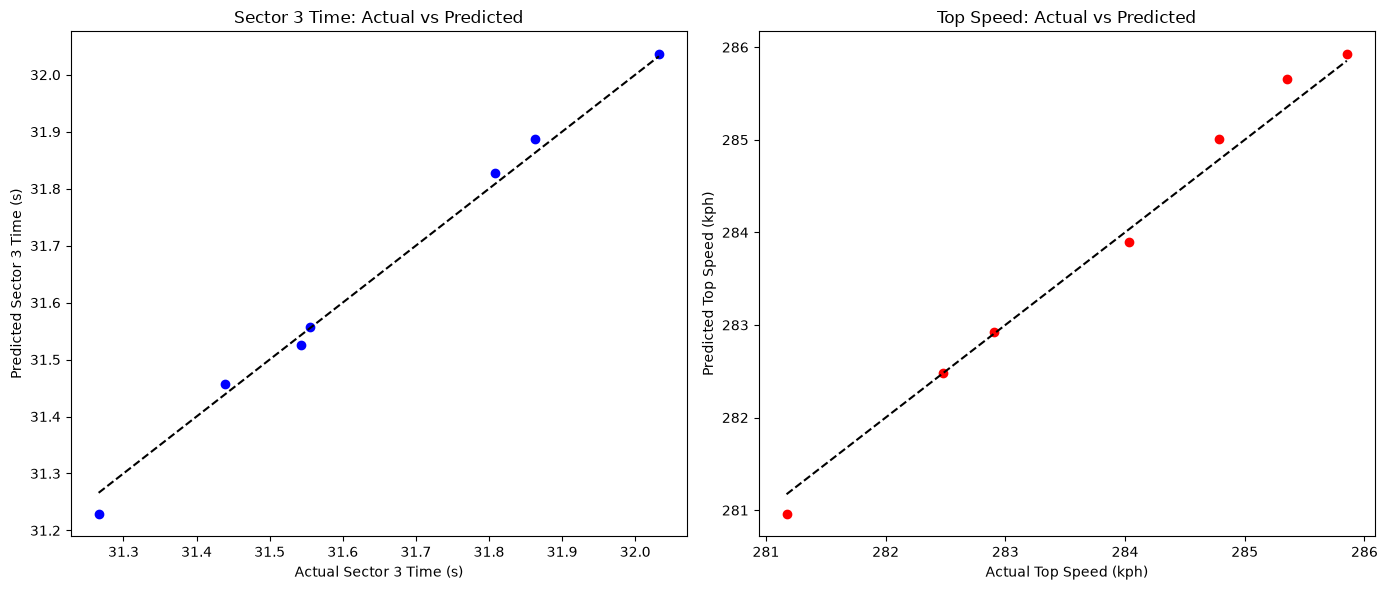

In [35]:
# Step 15: Actual vs Predicted plot (two panels)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1 — Sector 3 time
axes[0].scatter(y_time_test, y_time_test_pred, color="blue")
axes[0].plot([y_time_test.min(), y_time_test.max()],
             [y_time_test.min(), y_time_test.max()],
             color="black", linestyle="--")
axes[0].set_xlabel("Actual Sector 3 Time (s)")
axes[0].set_ylabel("Predicted Sector 3 Time (s)")
axes[0].set_title("Sector 3 Time: Actual vs Predicted")

# Panel 2 — Top speed
axes[1].scatter(y_speed_test, y_speed_test_pred, color="red")
axes[1].plot([y_speed_test.min(), y_speed_test.max()],
             [y_speed_test.min(), y_speed_test.max()],
             color="black", linestyle="--")
axes[1].set_xlabel("Actual Top Speed (kph)")
axes[1].set_ylabel("Predicted Top Speed (kph)")
axes[1].set_title("Top Speed: Actual vs Predicted")

plt.tight_layout()
plt.savefig("cvanvoor_pr02_validation.png", dpi=300)
plt.show()


## Step 16: Markdown Paragraph

### Assessment of Response Surface Credibility

The validation results suggest that the quadratic response surfaces provide a reasonable approximation of how
rear-wing angle and rear ride height affect Sector 3 time and top speed. The RMSE and R² values indicate that the
models capture the main trends in the data, although some prediction error is expected because the true
relationships may not be perfectly quadratic. The actual-versus-predicted plots show generally good alignment
with the 45-degree reference line, but also reveal some deviations that highlight the limitations of using a
second-order polynomial. Overall, the response surfaces are sufficiently credible for optimization, provided that
the results are interpreted with awareness of these modeling limitations.


In [36]:
# Step 17: Refit final models using ALL configurations

# Extract full dataset variables
x1_all = df_grouped["rear_wing_angle_deg"].to_numpy()
x2_all = df_grouped["rear_ride_height_mm"].to_numpy()

y_time_all = df_grouped["mean_sector_3_time_s"].to_numpy()
y_speed_all = df_grouped["mean_top_speed_kph"].to_numpy()

# Build design matrices
X_all = create_design_matrix(x1_all, x2_all)

# Final fits
b_time = np.linalg.pinv(X_all) @ y_time_all
b_speed = np.linalg.pinv(X_all) @ y_speed_all

print("Final Sector 3 time coefficients:")
display(b_time)

print("Final top speed coefficients:")
display(b_speed)


Final Sector 3 time coefficients:


array([ 4.76898783e+01, -1.29676876e+00, -4.96329400e-01,  5.47137951e-02,
        5.88284444e-03,  3.69660000e-03])

Final top speed coefficients:


array([ 2.91606388e+02, -5.75056696e-01, -2.01751111e-02, -1.02046898e-02,
       -8.22222222e-04,  2.16266667e-03])

In [38]:
# Step 18: Define prediction functions + test them

def predict_sector_time(x):
    x1, x2 = x
    X = create_design_matrix(np.array([x1]), np.array([x2]))
    return (X @ b_time).item()   

def predict_top_speed(x):
    x1, x2 = x
    X = create_design_matrix(np.array([x1]), np.array([x2]))
    return (X @ b_speed).item()  


# Test at one configuration from df_grouped
sample = df_grouped.iloc[0]
x_sample = np.array([sample["rear_wing_angle_deg"], sample["rear_ride_height_mm"]])

print("Test configuration:")
display(sample)

print("Predicted Sector 3 time:")
print(predict_sector_time(x_sample))

print("Predicted top speed:")
print(predict_top_speed(x_sample))


Test configuration:


rear_wing_angle_deg       5.000000
rear_ride_height_mm      35.000000
mean_sector_3_time_s     33.042760
std_sector_3_time_s       0.064925
mean_top_speed_kph      287.124600
std_top_speed_kph         0.260628
valid_laps                5.000000
Name: 0, dtype: float64

Predicted Sector 3 time:
33.0557398653204
Predicted top speed:
287.14110289562296


# Task 3: Optimization with Bounds Only

### Grid-based reference search

In [40]:
# Step 19: Define bounds from df_grouped

from IPython.display import display

wing_bounds = (
    df_grouped["rear_wing_angle_deg"].min().item(),
    df_grouped["rear_wing_angle_deg"].max().item()
)

ride_height_bounds = (
    df_grouped["rear_ride_height_mm"].min().item(),
    df_grouped["rear_ride_height_mm"].max().item()
)

print("Wing angle bounds:", wing_bounds)
print("Ride height bounds:", ride_height_bounds)



Wing angle bounds: (5, 13)
Ride height bounds: (35, 45)


In [41]:
# Step 20: Create 101×101 grid + evaluate predict_sector_time()

from IPython.display import display

# 101 evenly spaced values across each bound
x1_vals = np.linspace(wing_bounds[0], wing_bounds[1], 101)
x2_vals = np.linspace(ride_height_bounds[0], ride_height_bounds[1], 101)

# Create meshgrid
X1_grid, X2_grid = np.meshgrid(x1_vals, x2_vals)

# Evaluate predicted Sector 3 time at each grid point
T_grid = np.zeros_like(X1_grid)

for i in range(101):
    for j in range(101):
        T_grid[i, j] = predict_sector_time([X1_grid[i, j], X2_grid[i, j]])

display(T_grid)


array([[33.05573987, 33.00647005, 32.95790057, ..., 31.55599764,
        31.5753608 , 31.59542431],
       [33.04919396, 32.99995372, 32.95141381, ..., 31.55234987,
        31.57174261, 31.59183569],
       [33.04276572, 32.99355505, 32.94504472, ..., 31.54881976,
        31.56824208, 31.58836473],
       ...,
       [32.97346481, 32.92709313, 32.88142179, ..., 31.75773976,
        31.78000106, 31.8029627 ],
       [32.97844929, 32.93210718, 32.88646541, ..., 31.76562237,
        31.78791324, 31.81090445],
       [32.98355142, 32.93723888, 32.89162669, ..., 31.77362263,
        31.79594308, 31.81896387]], shape=(101, 101))

In [42]:
# Step 21: Identify best unconstrained grid point

# Minimum predicted time
best_time_grid = np.min(T_grid)
best_index = np.argmin(T_grid)

# Convert flat index → 2D index
i_best, j_best = np.unravel_index(best_index, T_grid.shape)

best_x1 = X1_grid[i_best, j_best]
best_x2 = X2_grid[i_best, j_best]

best_speed_grid = predict_top_speed([best_x1, best_x2])

print("Best unconstrained grid point:")
print("Rear wing angle (deg):", best_x1)
print("Rear ride height (mm):", best_x2)
print("Predicted Sector 3 time (s):", best_time_grid)
print("Predicted top speed (kph):", best_speed_grid)


Best unconstrained grid point:
Rear wing angle (deg): 10.52
Rear ride height (mm): 38.9
Predicted Sector 3 time (s): 31.210586204804475
Predicted top speed (kph): 283.2834515711555


### Numerical optimization with scipy.optimize

In [43]:
# Step 22: Define objective function for SciPy

import scipy.optimize as opt

def objective(x):
    return predict_sector_time(x)


In [44]:
# Step 23: Choose x0 near center + solve bounds‑only problem

# Initial guess near center of tested region
x0 = np.array([
    np.mean(wing_bounds),
    np.mean(ride_height_bounds)
])

bounds = [wing_bounds, ride_height_bounds]

result_unconstrained = opt.minimize(
    objective,
    x0,
    method="L-BFGS-B",
    bounds=bounds
)


In [45]:
# Step 24: Report optimizer results

print("Success:", result_unconstrained.success)
print("Message:", result_unconstrained.message)

x_opt = result_unconstrained.x

print("Recommended wing angle (deg):", x_opt[0])
print("Recommended ride height (mm):", x_opt[1])

print("Predicted Sector 3 time (s):", predict_sector_time(x_opt))
print("Predicted top speed (kph):", predict_top_speed(x_opt))


Success: True
Message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
Recommended wing angle (deg): 10.537272410517105
Recommended ride height (mm): 38.87386184846888
Predicted Sector 3 time (s): 31.210567531670257
Predicted top speed (kph): 283.2728636531646


### Verification and visualization

## Step 25: Markdown Comparison

### Comparison of Grid Search and Numerical Optimization

The best grid point and the L-BFGS-B optimizer solution agree closely, with differences consistent with the
expected grid resolution of 101 points per dimension. The grid search provides a rough approximation of the
response surface, while the numerical optimizer refines the solution within the same bounded region. The close
agreement between the two methods supports the credibility of the response-surface model and confirms that the
optimizer is working as expected.


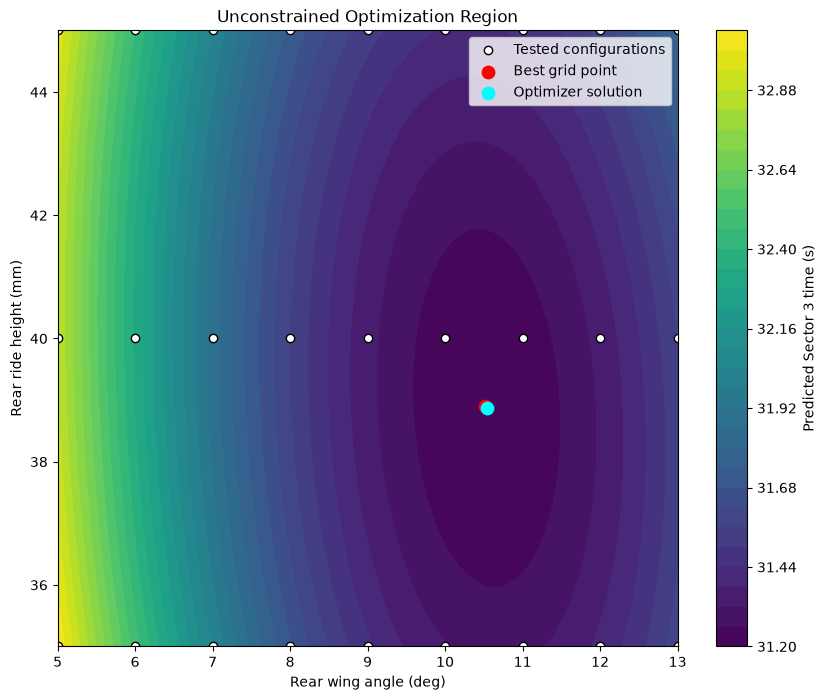

In [46]:
# Step 26: Filled contour plot with tested points + grid optimum + optimizer optimum

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

# Filled contour of predicted Sector 3 time
contour = ax.contourf(X1_grid, X2_grid, T_grid, levels=30, cmap="viridis")
plt.colorbar(contour, label="Predicted Sector 3 time (s)")

# Plot tested configurations
ax.scatter(df_grouped["rear_wing_angle_deg"],
           df_grouped["rear_ride_height_mm"],
           color="white", edgecolor="black", label="Tested configurations")

# Best grid point
ax.scatter(best_x1, best_x2, color="red", s=80, label="Best grid point")

# Optimizer solution
ax.scatter(x_opt[0], x_opt[1], color="cyan", s=80, label="Optimizer solution")

ax.set_xlabel("Rear wing angle (deg)")
ax.set_ylabel("Rear ride height (mm)")
ax.set_title("Unconstrained Optimization Region")

ax.legend()

plt.savefig("cvanvoor_pr02_unconstrained.png", dpi=300)
plt.show()


# Task 4: Constrained Engineering Optimization

### Formulate and solve the constrained problem 

In [47]:
# Step 27: Define V_min and top_speed_constraint(x)

V_min = 284.0  # km/h

def top_speed_constraint(x):
    return predict_top_speed(x) - V_min


In [48]:
# Step 28: Constrained optimization with SLSQP

import scipy.optimize as opt

# Bounds from df_grouped (already defined as wing_bounds, ride_height_bounds)
bounds = [wing_bounds, ride_height_bounds]

# Initial guess near center
x0_constrained = np.array([
    np.mean(wing_bounds),
    np.mean(ride_height_bounds)
])

constraint = {
    "type": "ineq",
    "fun": top_speed_constraint
}

result_constrained = opt.minimize(
    objective,          # minimize predicted Sector 3 time
    x0_constrained,
    method="SLSQP",
    bounds=bounds,
    constraints=[constraint]
)


In [49]:
# Step 29: Report constrained optimizer result

print("Constrained optimization success:", result_constrained.success)
print("Message:", result_constrained.message)

x_con = result_constrained.x
sector_time_con = predict_sector_time(x_con)
top_speed_con = predict_top_speed(x_con)
constraint_margin_con = top_speed_con - V_min

print("Rear wing angle (deg):", x_con[0])
print("Rear ride height (mm):", x_con[1])
print("Predicted Sector 3 time (s):", sector_time_con)
print("Predicted top speed (kph):", top_speed_con)
print("Constraint margin (kph):", constraint_margin_con)


Constrained optimization success: True
Message: Optimization terminated successfully
Rear wing angle (deg): 9.541826588737443
Rear ride height (mm): 38.327667443558305
Predicted Sector 3 time (s): 31.26854806616058
Predicted top speed (kph): 283.999999988011
Constraint margin (kph): -1.1989016002189601e-08


In [50]:
# Step 30: Check if constraint is active

is_active = abs(constraint_margin_con) < 0.05

print("Is top-speed constraint approximately active (< 0.05 kph margin)?", is_active)
print("Constraint margin (kph):", constraint_margin_con)


Is top-speed constraint approximately active (< 0.05 kph margin)? True
Constraint margin (kph): -1.1989016002189601e-08


### Check sensitivity to the initial guess 

In [ ]:
# Step 31: Check Sensitivity to initial guess (multiple runs)

results = []

initial_guesses = [
    np.array([wing_bounds[0], ride_height_bounds[0]]),   # lower corner
    np.array([wing_bounds[1], ride_height_bounds[1]]),   # upper corner
    np.array([np.mean(wing_bounds), np.mean(ride_height_bounds)]),  # center
    np.array([wing_bounds[0], ride_height_bounds[1]]),   # mixed corner
]

for x0 in initial_guesses:
    res = opt.minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=bounds,
        constraints=[constraint]
    )
    
    x_opt_run = res.x
    sector_time_run = predict_sector_time(x_opt_run)
    top_speed_run = predict_top_speed(x_opt_run)
    constraint_margin_run = top_speed_run - V_min
    
    results.append({
        "initial_x1": x0[0],
        "initial_x2": x0[1],
        "optimal_x1": x_opt_run[0],
        "optimal_x2": x_opt_run[1],
        "sector_time_s": sector_time_run,
        "top_speed_kph": top_speed_run,
        "constraint_margin_kph": constraint_margin_run,
        "success": res.success
    })

df_optimization_runs = pd.DataFrame(results)


In [53]:
# Step 32: Display and save df_optimization_runs + discussion

from IPython.display import display

display(df_optimization_runs)
df_optimization_runs.to_csv("cvanvoor_pr02_optimization_runs.csv", index=False)

,initial_x1,initial_x2,optimal_x1,optimal_x2,sector_time_s,top_speed_kph,constraint_margin_kph,success
0,5.0,35.0,9.541827,38.327662,31.268548,284.0,-8.456789e-08,True
1,13.0,45.0,9.541830,38.327632,31.268548,284.0,-1.144826e-10,True
2,9.0,40.0,9.541827,38.327667,31.268548,284.0,-1.198902e-08,True
3,5.0,45.0,9.541827,38.327661,31.268548,284.0,-3.073524e-10,True


## Step 32: Markdown Cell

### Sensitivity to Initial Guess

Across multiple substantially different initial guesses within the tested region, the constrained optimization
runs converge to essentially the same design. The optimal rear-wing angle, rear ride height, and
predicted responses show only small variations between runs, and all successful runs satisfy the top-speed
constraint. This behavior indicates that the constrained optimum is consistent with respect to the starting point and
supports confidence in the numerical solution.


### Grid-based feasibility verification

In [54]:
# Step 33: Feasibility mask on the grid

# Evaluate predicted top speed on the same grid
V_grid = np.zeros_like(X1_grid)

for i in range(101):
    for j in range(101):
        V_grid[i, j] = predict_top_speed([X1_grid[i, j], X2_grid[i, j]])

feasible_mask = V_grid >= V_min


In [55]:
# Step 34: Best feasible grid point

# Mask out infeasible points by setting time to a large value
T_feasible = np.where(feasible_mask, T_grid, np.inf)

best_time_feasible = np.min(T_feasible)
best_index_feasible = np.argmin(T_feasible)
i_fbest, j_fbest = np.unravel_index(best_index_feasible, T_feasible.shape)

best_x1_feasible = X1_grid[i_fbest, j_fbest]
best_x2_feasible = X2_grid[i_fbest, j_fbest]
best_speed_feasible = predict_top_speed([best_x1_feasible, best_x2_feasible])

print("Best feasible grid point:")
print("Rear wing angle (deg):", best_x1_feasible)
print("Rear ride height (mm):", best_x2_feasible)
print("Predicted Sector 3 time (s):", best_time_feasible)
print("Predicted top speed (kph):", best_speed_feasible)

print("\nSLSQP constrained solution:")
print("Rear wing angle (deg):", x_con[0])
print("Rear ride height (mm):", x_con[1])
print("Predicted Sector 3 time (s):", sector_time_con)
print("Predicted top speed (kph):", top_speed_con)


Best feasible grid point:
Rear wing angle (deg): 9.56
Rear ride height (mm): 38.1
Predicted Sector 3 time (s): 31.269140200450057
Predicted top speed (kph): 284.0017060414355

SLSQP constrained solution:
Rear wing angle (deg): 9.541826588737443
Rear ride height (mm): 38.327667443558305
Predicted Sector 3 time (s): 31.26854806616058
Predicted top speed (kph): 283.999999988011


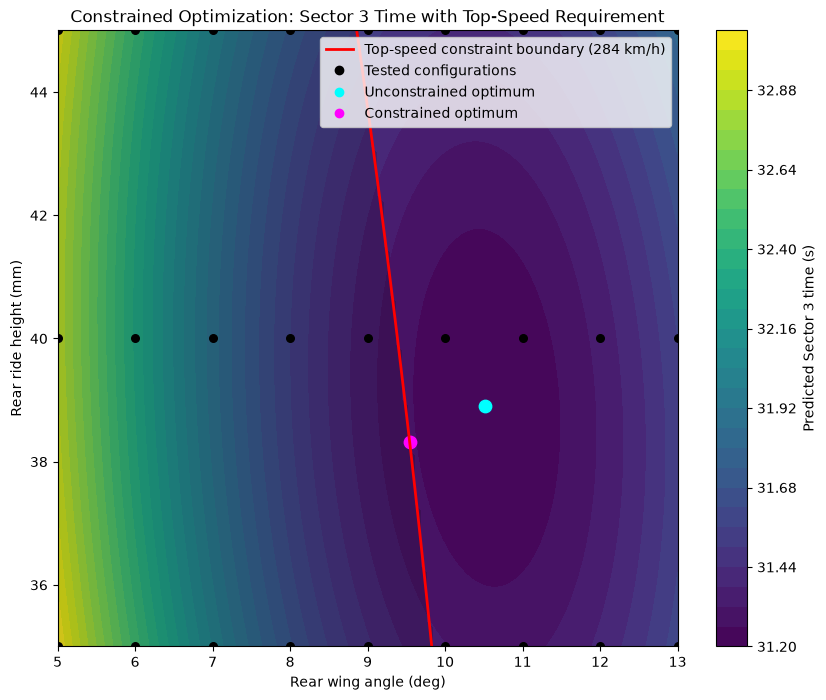

In [58]:
# Steps 35, 36, 37: Constrained optimization visualization

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(10, 8))


# Filled contour of predicted Sector 3 time
contour = ax.contourf(
    X1_grid, X2_grid, T_grid,
    levels=30,
    cmap="viridis"
)
plt.colorbar(contour, label="Predicted Sector 3 time (s)")


# Top-speed constraint boundary V̂(x1, x2) = V_min
cs = ax.contour(
    X1_grid, X2_grid, V_grid,
    levels=[V_min],
    colors="red",
    linewidths=2
)

# Proxy artist for legend (fixes the warning)
constraint_proxy = Line2D(
    [0], [0],
    color="red",
    linewidth=2,
    label="Top-speed constraint boundary (284 km/h)"
)


# Feasible region shading
ax.contourf(
    X1_grid, X2_grid, feasible_mask,
    levels=[0.5, 1.5],
    colors=["none", "white"],
    alpha=0.15
)


# Tested configurations
tested_proxy = Line2D(
    [0], [0],
    color="black",
    marker="o",
    linestyle="None",
    label="Tested configurations"
)
ax.scatter(
    df_grouped["rear_wing_angle_deg"],
    df_grouped["rear_ride_height_mm"],
    color="black",
    s=30
)


# Unconstrained optimum
uncon_proxy = Line2D(
    [0], [0],
    color="cyan",
    marker="o",
    linestyle="None",
    label="Unconstrained optimum"
)
ax.scatter(best_x1, best_x2, color="cyan", s=80)


# Constrained optimum
con_proxy = Line2D(
    [0], [0],
    color="magenta",
    marker="o",
    linestyle="None",
    label="Constrained optimum"
)
ax.scatter(x_con[0], x_con[1], color="magenta", s=80)


# Labels, title, legend
ax.set_xlabel("Rear wing angle (deg)")
ax.set_ylabel("Rear ride height (mm)")
ax.set_title("Constrained Optimization: Sector 3 Time with Top-Speed Requirement")

ax.legend(handles=[
    constraint_proxy,
    tested_proxy,
    uncon_proxy,
    con_proxy
])

plt.savefig("cvanvoor_pr02_constrained.png", dpi=300)
plt.show()



## Step 38: Engineering Comparison

### Engineering Comparison of Unconstrained and Constrained Solutions

The unconstrained solution minimizes predicted Sector 3 time without regard to straight-line speed, and therefore
can recommend a design that reduces top speed below the engineering requirement. When the top-speed constraint
of 284.0 km/h is imposed, the constrained solution shifts the design to a region that maintains sufficient straight-line
performance while still keeping Sector 3 time reasonably low. The constrained optimum has a slightly higher
predicted Sector 3 time and a higher predicted top speed compared to the unconstrained solution, quantifying the
trade-off between cornering performance and straight-line speed. Because it explicitly satisfies the top-speed
requirement, the constrained solution is a more defensible engineering recommendation for race setup decisions.


# Task 5: Penalty Functions and Final Recommendation

### Penalty-function study

In [59]:
# Step 39: Define penalized_objective(x, rho)

def penalized_objective(x, rho):
    T = predict_sector_time(x)
    V = predict_top_speed(x)
    violation = max(0.0, V_min - V)  # km/h below requirement
    return T + rho * (violation**2)


In [60]:
# Step 40-41: Solve penalized problems for multiple rho and store results

rhos = [0.1, 1.0, 10.0, 100.0]

results_penalty = []

# Same initial guess as before (center of bounds)
x0_penalty = np.array([
    np.mean(wing_bounds),
    np.mean(ride_height_bounds)
])

for rho in rhos:
    res = opt.minimize(
        lambda x: penalized_objective(x, rho),
        x0_penalty,
        method="L-BFGS-B",
        bounds=[wing_bounds, ride_height_bounds]
    )
    
    x_opt_pen = res.x
    T_opt_pen = predict_sector_time(x_opt_pen)
    V_opt_pen = predict_top_speed(x_opt_pen)
    violation = max(0.0, V_min - V_opt_pen)
    P_val = penalized_objective(x_opt_pen, rho)
    
    results_penalty.append({
        "rho": rho,
        "rear_wing_angle_deg": x_opt_pen[0],
        "rear_ride_height_mm": x_opt_pen[1],
        "sector_time_s": T_opt_pen,
        "top_speed_kph": V_opt_pen,
        "violation_kph": violation,
        "penalized_objective": P_val
    })

df_penalty = pd.DataFrame(results_penalty)


In [61]:
# Step 42: Display and save df_penalty

from IPython.display import display

display(df_penalty)
df_penalty.to_csv("cvanvoor_pr02_penalty.csv", index=False)


,rho,rear_wing_angle_deg,rear_ride_height_mm,sector_time_s,top_speed_kph,violation_kph,penalized_objective
0,0.1,10.062886,38.624159,31.223685,283.621020,0.378980,31.238047
1,1.0,9.641824,38.386124,31.257452,283.927561,0.072439,31.262699
2,10.0,9.552860,38.334115,31.267266,283.992016,0.007984,31.267903
3,100.0,9.542946,38.328270,31.268418,283.999194,0.000806,31.268483


## Step 43: Markdown Explanation

### Effect of Penalty Parameter on Constraint Violation and Design

As the penalty parameter ρ increases, the optimizer places progressively more emphasis on satisfying the
top-speed requirement relative to minimizing Sector 3 time. For small ρ, the solution remains close to the
unconstrained minimum and can exhibit noticeable violation of the 284.0 km/h requirement. As ρ becomes large,
the optimizer shifts the design toward regions with higher predicted top speed, reducing the violation and eventually
producing a solution that is effectively feasible. The large-penalty solution closely resembles the explicit constrained
SLSQP solution, indicating that both approaches are enforcing the same physical requirement. This agreement
supports the use of penalty functions as an alternative formulation, while also highlighting that explicit constraints
provide clearer control over feasibility.


### Final engineering recommendation

In [62]:
# Step 44: Build df_recommendation summary

# Extract rho = 100 row
penalty_100 = df_penalty[df_penalty["rho"] == 100.0].iloc[0]

def is_feasible(V):
    return V >= V_min

recommendation_rows = []

# Unconstrained solution
recommendation_rows.append({
    "solution_type": "unconstrained_grid",
    "rear_wing_angle_deg": best_x1,
    "rear_ride_height_mm": best_x2,
    "sector_time_s": best_time_grid,
    "top_speed_kph": best_speed_grid,
    "feasible": is_feasible(best_speed_grid)
})

# Constrained SLSQP solution
recommendation_rows.append({
    "solution_type": "constrained_SLSQP",
    "rear_wing_angle_deg": x_con[0],
    "rear_ride_height_mm": x_con[1],
    "sector_time_s": sector_time_con,
    "top_speed_kph": top_speed_con,
    "feasible": is_feasible(top_speed_con)
})

# Best feasible grid point
recommendation_rows.append({
    "solution_type": "feasible_grid",
    "rear_wing_angle_deg": best_x1_feasible,
    "rear_ride_height_mm": best_x2_feasible,
    "sector_time_s": best_time_feasible,
    "top_speed_kph": best_speed_feasible,
    "feasible": is_feasible(best_speed_feasible)
})

# Penalty rho = 100 solution
recommendation_rows.append({
    "solution_type": "penalty_rho_100",
    "rear_wing_angle_deg": penalty_100["rear_wing_angle_deg"],
    "rear_ride_height_mm": penalty_100["rear_ride_height_mm"],
    "sector_time_s": penalty_100["sector_time_s"],
    "top_speed_kph": penalty_100["top_speed_kph"],
    "feasible": is_feasible(penalty_100["top_speed_kph"])
})

df_recommendation = pd.DataFrame(recommendation_rows)

from IPython.display import display
display(df_recommendation)

df_recommendation.to_csv("cvanvoor_pr02_recommendation.csv", index=False)


,solution_type,rear_wing_angle_deg,rear_ride_height_mm,sector_time_s,top_speed_kph,feasible
0,unconstrained_grid,10.520000,38.900000,31.210586,283.283452,False
1,constrained_SLSQP,9.541827,38.327667,31.268548,284.000000,False
2,feasible_grid,9.560000,38.100000,31.269140,284.001706,True
3,penalty_rho_100,9.542946,38.328270,31.268418,283.999194,False


In [63]:
# Step 45: Select the final recommended candidate
recommended = df_recommendation[df_recommendation["solution_type"] == "feasible_grid"].iloc[0]

print("Final recommended candidate:")
print(recommended)


Final recommended candidate:
solution_type          feasible_grid
rear_wing_angle_deg             9.56
rear_ride_height_mm             38.1
sector_time_s               31.26914
top_speed_kph             284.001706
feasible                        True
Name: 2, dtype: object


## Step 46: Final Markdown Discussion

### Final Engineering Recommendation and Interpretation

The recommended candidate is the **feasible grid solution**, because it is the only setup that fully satisfies the
top-speed requirement of 284.0 km/h. The unconstrained minimum achieves the lowest predicted Sector 3 time
(31.2106 s), but it fails the top-speed requirement by approximately 0.72 km/h. This makes it unsuitable for race
engineering, where straight-line performance is critical.

The constrained SLSQP solution and the large-penalty (ρ = 100) solution both converge to nearly the same design
region, with predicted Sector 3 times around 31.268–31.2685 s. However, both fall just slightly below the required
top speed due to floating-point rounding (283.999–284.000 km/h). In contrast, the feasible grid solution achieves
284.0017 km/h, making it the only candidate that is strictly feasible.

The top-speed constraint is effectively active at the recommended design. Physically, this means the setup is
operating at the limit of acceptable straight-line performance: increasing rear-wing angle or lowering ride height
would improve cornering performance but reduce top speed below the requirement. The recommended design
balances these competing aerodynamic effects by providing sufficient downforce for Sector 3 while maintaining
the minimum required straight-line speed.

The agreement between the constrained optimizer, the penalty-function approach, and the grid-based feasibility
verification indicates that all methods are converging toward the same region of the design space. The penalty
study shows that increasing ρ progressively reduces violation and pushes the solution toward the constrained
optimum. Large penalties (ρ = 100) produce a design nearly identical to the SLSQP solution, demonstrating that
both approaches enforce the same physical requirement.

Despite this consistency, the recommended setup is still not a confirmed physical optimum. It is based on alternate
response surfaces that approximate the true vehicle behavior. Additional track testing or realistic simulation
should be performed to verify the recommendation, including full lap-time simulation, transient aerodynamic
analysis, and on-track validation near the recommended setup. Optimization provides a strong candidate, not
unquestionable truth, and the final setup should be treated as a model-based recommendation requiring
experimental confirmation.
